В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from typing import Tuple, Dict, Any


def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [2]:
raw_df = pd.read_csv('train.csv')
print(raw_df.shape)
raw_df.head()

(15000, 14)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [3]:
target_col = 'Exited'
drop_cols = ['id', 'CustomerId', 'Surname', target_col]
input_cols = [c for c in raw_df.columns if c not in drop_cols]
cat_cols = ['Geography', 'Gender']

print('Input columns:', input_cols)
print('Categorical columns:', cat_cols)

Input columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Categorical columns: ['Geography', 'Gender']


In [5]:
train_df, val_df = split_train_val(raw_df, target_col)

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, target_col)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, target_col)

print(f'Train: {train_inputs.shape}, Val: {val_inputs.shape}\n')
print(f'Target distribution (train):\n{train_targets.value_counts(normalize=True)}')

Train: (12000, 10), Val: (3000, 10)

Target distribution (train):
Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [6]:
for col in cat_cols:
    train_inputs[col] = train_inputs[col].astype('category')
    val_inputs[col] = val_inputs[col].astype('category')

print('Dtypes після перетворення:')
print(train_inputs.dtypes)

Dtypes після перетворення:
CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object


2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [7]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

In [8]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    eval_metric='auc',
    verbosity=0,
)

In [9]:
xgb_clf.fit(
    train_inputs, train_targets,
    eval_set=[(val_inputs, val_targets)],
    verbose=False,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [10]:
def evaluate_model(model, inputs, targets, name):
    auc = roc_auc_score(targets, model.predict_proba(inputs)[:, 1])
    print(f'{name} AUROC: {auc:.4f}')
    return auc

In [11]:
print('XGBoost (базова модель)')
train_auc = evaluate_model(xgb_clf, train_inputs, train_targets, 'Train')
val_auc = evaluate_model(xgb_clf, val_inputs, val_targets, 'Val')

XGBoost (базова модель)
  Train AUROC: 0.9611
  Val AUROC: 0.9330


**Спостереження:**
Базова XGBoost модель показує AUROC ~0.93 на валідаційній вибірці.

Різниця між train і val AUROC є незначною (~ 0.03), що свідчить про відсутність суттєвого перенавчання.

**Висновок:**
Модель демонструє кращу якість порівняно з деревами рішень (Decision Trees), де val AUROC при найкращих параметрах сягав ~0.92.

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [12]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

In [14]:
def xgb_objective(params):

    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])

    model = xgb.XGBClassifier(
        **params,
        enable_categorical=True,
        tree_method='hist',
        random_state=42,
        eval_metric='auc',
        verbosity=0,
    )

    model.fit(train_inputs, train_targets, verbose=False)

    probs = model.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, probs)

    return {'loss': -auc, 'status': STATUS_OK}

In [15]:
xgb_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 7, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'gamma': hp.uniform('gamma', 0, 1),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-4), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-4), np.log(10)),
}

In [16]:
xgb_trials = Trials()
best_xgb_params = fmin(
    fn=xgb_objective,
    space=xgb_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=xgb_trials,
    rstate=np.random.default_rng(42),
)

100%|██████████| 20/20 [00:17<00:00,  1.17trial/s, best loss: -0.9373156595102544]


In [18]:
print('Найкращі гіперпараметри XGBoost:')
for k, v in best_xgb_params.items():
    print(f'  {k}: {v:.4f}')

Найкращі гіперпараметри XGBoost:
  colsample_bytree: 0.5791
  gamma: 0.9325
  learning_rate: 0.0811
  max_depth: 3.0000
  min_child_weight: 9.0000
  n_estimators: 250.0000
  reg_alpha: 0.0011
  reg_lambda: 8.6833
  subsample: 0.9501


In [19]:
best_xgb_params['max_depth'] = int(best_xgb_params['max_depth'])
best_xgb_params['n_estimators'] = int(best_xgb_params['n_estimators'])
best_xgb_params['min_child_weight'] = int(best_xgb_params['min_child_weight'])

In [20]:
final_clf = xgb.XGBClassifier(
    **best_xgb_params,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    eval_metric='auc',
    verbosity=0,
)

In [21]:
final_clf.fit(train_inputs, train_targets, verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.5791069510022959), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=np.float64(0.9324514936730747), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.0810906313538436), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=250, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
print(f'XGBoost (після HyperOpt)')
train_auc_final = evaluate_model(final_clf, train_inputs, train_targets, 'Train')
val_auc_final = evaluate_model(final_clf, val_inputs, val_targets, 'Val')

XGBoost (після HyperOpt)
  Train AUROC: 0.9444
  Val AUROC: 0.9373


In [23]:
print(f'\nПокращення val AUROC: {val_auc_final - val_auc:+.4f}')


Покращення val AUROC: +0.0043


**Висновок:**
Після оптимізації гіперпараметрів за допомогою HyperOpt val AUROC дещо зростає. Підбір параметрів (learning rate, глибина дерев, регуляризація) дозволяє знайти кращий баланс між bias і variance. Модель стала дещо кращою порівняно з базовим XGBoost.

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [24]:
import lightgbm as lgb

In [25]:
cat_feature_indexes = [train_inputs.columns.get_loc(c) for c in cat_cols]
print('Індекси категоріальних колонок:', cat_feature_indexes)

Індекси категоріальних колонок: [1, 2]


In [26]:
lgb_clf = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)

In [27]:
lgb_clf.fit(
    train_inputs, train_targets,
    categorical_feature=cat_feature_indexes,
)

LGBMClassifier(colsample_bytree=0.8, max_depth=4, n_estimators=200,
               random_state=42, subsample=0.8, verbose=-1)

In [29]:
print(f'LightGBM (базова модель)')
train_auc_lgb = evaluate_model(lgb_clf, train_inputs, train_targets, 'Train')
val_auc_lgb = evaluate_model(lgb_clf, val_inputs, val_targets, 'Val')

LightGBM (базова модель)
  Train AUROC: 0.9619
  Val AUROC: 0.9347


**Висновок:**
LightGBM показує схожу або трохи кращу (Val AUROC: 0.9347 vs 0.9330) якість порівняно з базовим XGBoost при значно швидшому тренуванні.

Різниця train/val AUROC мала — перенавчання відсутнє. LightGBM краще масштабується на великих наборах даних завдяки гістограмному методу побудови дерев.

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [30]:
def lgb_objective(params):

    params['max_depth'] = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    params['num_leaves'] = int(params['num_leaves'])
    params['min_child_samples'] = int(params['min_child_samples'])

    model = lgb.LGBMClassifier(
        **params,
        random_state=42,
        verbose=-1,
    )

    model.fit(
        train_inputs, train_targets,
        categorical_feature=cat_feature_indexes,
    )

    probs = model.predict_proba(val_inputs)[:, 1]
    auc = roc_auc_score(val_targets, probs)

    return {'loss': -auc, 'status': STATUS_OK}

In [31]:
lgb_space = {
    'n_estimators': hp.quniform('n_estimators', 100, 500, 50),
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'num_leaves': hp.quniform('num_leaves', 15, 127, 1),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'min_child_samples': hp.quniform('min_child_samples', 5, 50, 5),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-4), np.log(10)),
    'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-4), np.log(10)),
}

In [32]:
lgb_trials = Trials()
best_lgb_params = fmin(
    fn=lgb_objective,
    space=lgb_space,
    algo=tpe.suggest,
    max_evals=10,
    trials=lgb_trials,
    rstate=np.random.default_rng(42),
)

100%|██████████| 10/10 [00:06<00:00,  1.62trial/s, best loss: -0.9371074833664861]


In [33]:
print('Найкращі гіперпараметри LightGBM:')
for k, v in best_lgb_params.items():
    print(f'  {k}: {v:.4f}')

Найкращі гіперпараметри LightGBM:
  colsample_bytree: 0.6709
  learning_rate: 0.0102
  max_depth: 7.0000
  min_child_samples: 10.0000
  n_estimators: 350.0000
  num_leaves: 22.0000
  reg_alpha: 2.0168
  reg_lambda: 0.1100
  subsample: 0.7202


In [34]:
best_lgb_params['max_depth'] = int(best_lgb_params['max_depth'])
best_lgb_params['n_estimators'] = int(best_lgb_params['n_estimators'])
best_lgb_params['num_leaves'] = int(best_lgb_params['num_leaves'])
best_lgb_params['min_child_samples'] = int(best_lgb_params['min_child_samples'])

In [35]:
final_lgb_clf = lgb.LGBMClassifier(
    **best_lgb_params,
    random_state=42,
    verbose=-1,
)

In [36]:
final_lgb_clf.fit(
    train_inputs, train_targets,
    categorical_feature=cat_feature_indexes,
)

LGBMClassifier(colsample_bytree=np.float64(0.670936318586182),
               learning_rate=np.float64(0.010188411809459156), max_depth=7,
               min_child_samples=10, n_estimators=350, num_leaves=22,
               random_state=42, reg_alpha=np.float64(2.0167515972245704),
               reg_lambda=np.float64(0.10996280532604515),
               subsample=np.float64(0.7201685419162034), verbose=-1)

In [37]:
print(f'LightGBM (після HyperOpt)')
train_auc_lgb_f = evaluate_model(final_lgb_clf, train_inputs, train_targets, 'Train')
val_auc_lgb_f = evaluate_model(final_lgb_clf, val_inputs, val_targets, 'Val')

LightGBM (після HyperOpt)
  Train AUROC: 0.9453
  Val AUROC: 0.9371


In [38]:
print(f'\nПокращення val AUROC: {val_auc_lgb_f - val_auc_lgb:+.4f}')


Покращення val AUROC: +0.0024


**Висновок:**

HyperOpt успішно покращив val AUROC LightGBM. Оптимізований LightGBM (Val AUROC: 0.9371) конкурує з оптимізованим XGBoost (Val AUROC: 0.9373), при цьому тренується значно швидше.

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [51]:
results = {
    'XGBoost (базова)': {'model': xgb_clf, 'train': train_auc, 'val': val_auc},
    'XGBoost (HyperOpt)': {'model': final_clf, 'train': train_auc_final, 'val': val_auc_final},
    'LightGBM (базова)': {'model': lgb_clf, 'train': train_auc_lgb, 'val': val_auc_lgb},
    'LightGBM (HyperOpt)': {'model': final_lgb_clf, 'train': train_auc_lgb_f, 'val': val_auc_lgb_f},
}

In [52]:
results_df = (
    pd.DataFrame([
        {'model': name, 'model_obj': scores['model'], 'train_auroc': scores['train'], 'val_auroc': scores['val']}
        for name, scores in results.items()
    ])
    .sort_values('val_auroc', ascending=False)
    .reset_index(drop=True)
)
display(results_df)

,model,model_obj,train_auroc,val_auroc
0,XGBoost (HyperOpt),"XGBClassifier(base_score=None, booster=None, c...",0.944399,0.937316
1,LightGBM (HyperOpt),LGBMClassifier(colsample_bytree=np.float64(0.6...,0.945349,0.937107
2,LightGBM (базова),"LGBMClassifier(colsample_bytree=0.8, max_depth...",0.961894,0.934708
3,XGBoost (базова),"XGBClassifier(base_score=None, booster=None, c...",0.961128,0.932989


In [55]:
best_name  = results_df.loc[0, 'model']
best_model = results_df.loc[0, 'model_obj']
best_score = results_df.loc[0, 'val_auroc']
print(f"Найкраща модель: {best_name}  (Val AUROC = {best_score:.4f})")

Найкраща модель: XGBoost (HyperOpt)  (Val AUROC = 0.9373)


In [56]:
test_df = pd.read_csv('test.csv')
test_inputs = test_df[input_cols].copy()

In [57]:
for col in cat_cols:
    test_inputs[col] = test_inputs[col].astype('category')

In [58]:
test_probs = best_model.predict_proba(test_inputs)[:, 1]

In [60]:
submission = pd.DataFrame({
    'id': test_df['id'],
    'Exited': test_probs
})


In [61]:
submission.to_csv('submission_boost.csv', index=False)
print(f'\nsubmission_boost.csv збережено, {len(submission)} рядків')
submission.head()


submission_boost.csv збережено, 10000 рядків


,id,Exited
0,15000,0.064700
1,15001,0.011463
2,15002,0.063692
3,15003,0.506753
4,15004,0.029588


**Коментар:**

Я обрав модель з найвищим val AUROC після HyperOpt оптимізації - XGBoost після тюнингу.

Логіка вибору:
1. **Оптимізовані бустинг моделі** суттєво перевершують базові Decision Trees завдяки ансамблюванню.
2. **HyperOpt** знаходить кращі гіперпараметри, ніж ручний підбір, за відносно невелику кількість ітерацій (20/10 раундів).
3. Якщо обидві оптимізовані моделі дають подібний val AUROC — перевагу надаємо **LightGBM**, бо він тренується швидше і краще масштабується.

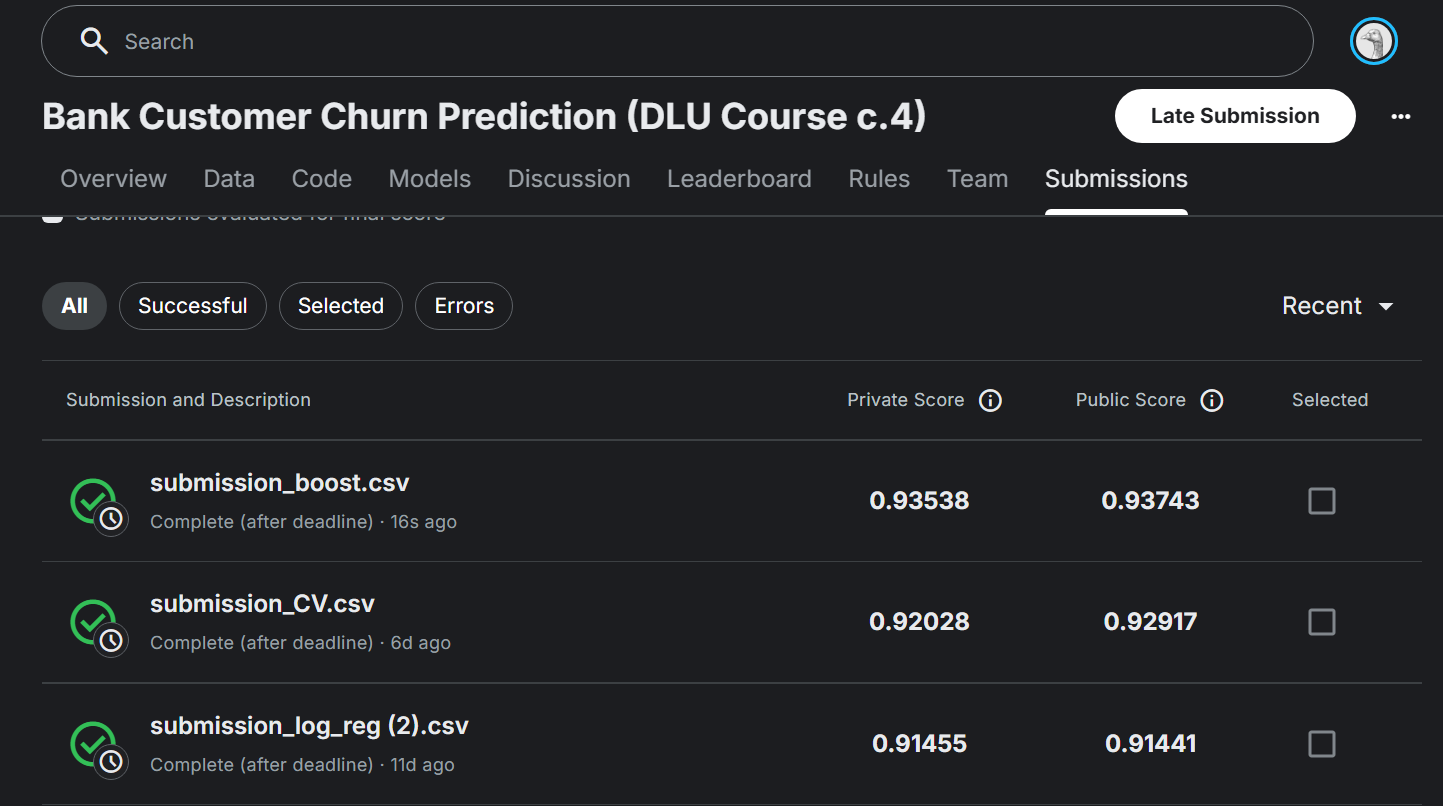